In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
# Apply the default theme
sns.set_theme()

In [3]:
# data_url = "https://raw.githubusercontent.com/dthonon/pna_loup_suivi/main/data/"
data_url = Path(os.getcwd()).parents[-5] / "data"
# Lecture du fichier CSV
data = pd.read_csv(data_url / "aquila_2000.csv")

In [4]:
data["Temps"] = data["Pas"] / 3600
data.head()

,Pas,Contrôle,V0(V),V1(V),I(mA),E(mAh),Temps
0,0,0,0.001612,0.001612,0.000000,0.000000,0.000000
1,1,1,0.195066,1.468637,84.904739,0.023585,0.000278
2,2,1,0.191842,1.462189,84.689790,0.047110,0.000556
3,3,1,0.008061,0.008061,0.000000,0.047110,0.000833
4,4,1,0.188617,1.391255,80.175867,0.069381,0.001111


In [5]:
# Séparer data en 2 DataFrames selon la valeur de la colonne "Contrôle"
data_controle_0 = data[data["Contrôle"] == 0].copy()
data_controle_1 = data[data["Contrôle"] == 1].copy()

print("Contrôle = 0 :", data_controle_0.shape[0], "lignes")
print("Contrôle = 1 :", data_controle_1.shape[0], "lignes")

Contrôle = 0 : 139 lignes
Contrôle = 1 : 83230 lignes


In [35]:
win_size_0 = 5
data_controle_0["V_smooth"] = data_controle_0["V1(V)"].rolling(window=win_size_0, center=True).mean()
data_controle_0["I_smooth"] = data_controle_0["I(mA)"].rolling(window=win_size_0, center=True).mean()

win_size_1 = 61
data_controle_1["V_smooth"] = data_controle_1["V1(V)"].rolling(window=win_size_1, center=True).mean()
data_controle_1["I_smooth"] = data_controle_1["I(mA)"].rolling(window=win_size_1, center=True).mean()
data_controle_1["E_smooth"] = data_controle_1["E(mAh)"].rolling(window=win_size_1, center=True).mean()

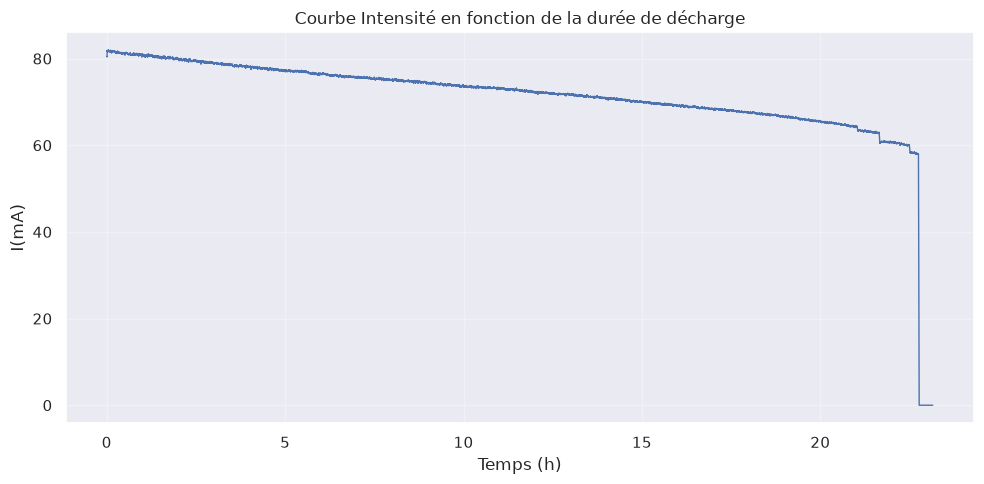

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_1["Temps"], data_controle_1["I_smooth"], marker="", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("I(mA)")
plt.title("Courbe Intensité en fonction de la durée de décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

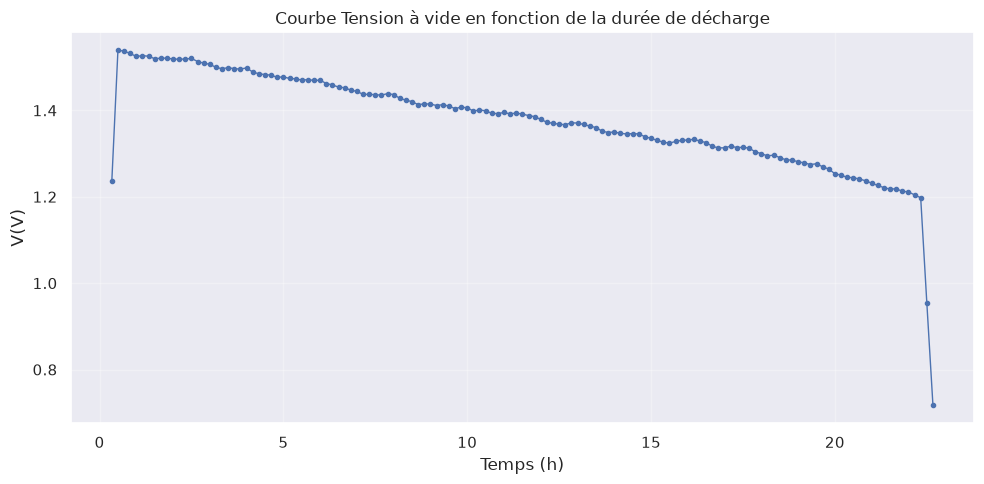

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_0["Temps"], data_controle_0["V_smooth"], marker=".", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("V(V)")
plt.title("Courbe Tension à vide en fonction de la durée de décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

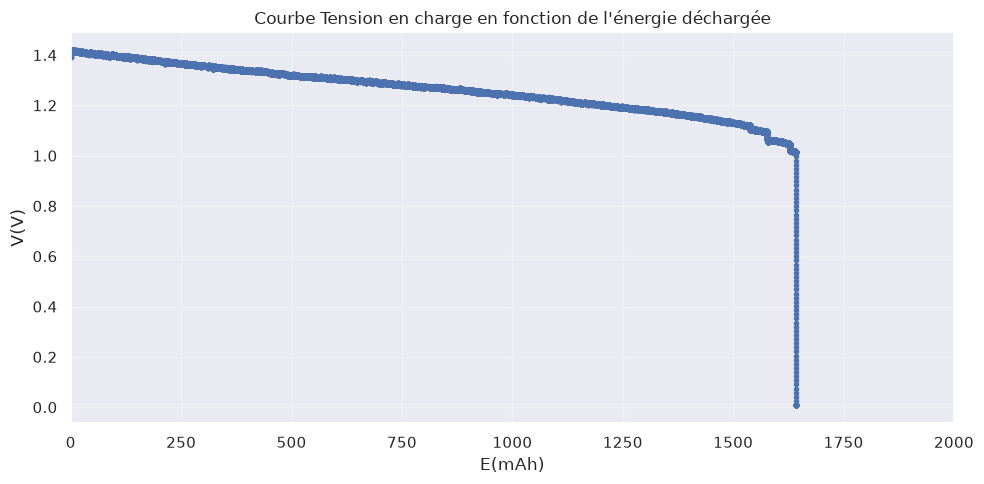

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_1["E_smooth"], data_controle_1["V_smooth"], marker=".", linewidth=1)
plt.xlim(0, 2000)
plt.xlabel("E(mAh)")
plt.ylabel("V(V)")
plt.title("Courbe Tension en charge en fonction de l'énergie déchargée")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

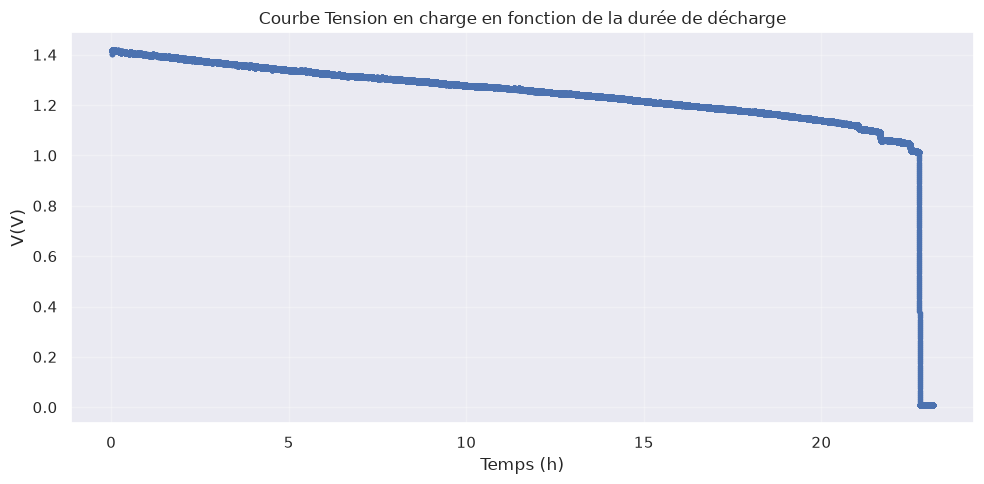

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(data_controle_1["Temps"], data_controle_1["V_smooth"], marker=".", linewidth=1)
plt.xlabel("Temps (h)")
plt.ylabel("V(V)")
plt.title("Courbe Tension en charge en fonction de la durée de décharge")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()